# ASR Analysis: Average Max Score vs Number of Rounds (Multi-turn Only)

This notebook analyzes the relationship between average maximum score and the number of rounds for multi-turn scenarios.
For r rounds, we consider the maximum score over the first r rounds instead of the maximum over all rounds.
This is only applicable to multi-turn data which has up to 8 rounds.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from pathlib import Path
from typing import Dict, List, Optional

# Set style to match reference notebooks
plt.style.use('default')

In [2]:
def get_max_score_by_round(data, max_rounds):
    """
    Get the maximum numeric score over the first r rounds for r = 1 to max_rounds.
    
    Args:
        data: a JSON string containing the attack entries
        max_rounds: Maximum number of rounds to consider
        
    Returns:
        Dictionary with keys 'max_score_by_r_rounds' for r = 1 to max_rounds
    """
    # Parse data if it's a string
    if isinstance(data, str):
        entries = []
        for line in data.strip().split('\n'):
            if line.strip():
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    continue

    # Extract numeric scores from entries (skip metadata entry)
    scores = []
    for entry in entries:
        # Skip the first entry if it's metadata (contains target_base_url, etc.)
        if 'target_base_url' in entry:
            continue
            
        score = entry.get('score')
        # Only consider numeric scores
        if isinstance(score, (int, float)):
            scores.append(score)
        else:
            # For non-numeric scores (like "refused"), treat as 0
            scores.append(0.0)
    
    # Calculate max score over first r rounds
    result = {}
    for r in range(1, max_rounds + 1):
        if r <= len(scores):
            max_score = max(scores[:r]) if scores[:r] else 0.0
        else:
            # If we don't have r rounds, use all available scores
            max_score = max(scores) if scores else 0.0
        result[f'max_score_by_{r}_rounds'] = max_score
    
    return result

def read_json_file(file_path):
    """
    Read a JSON file and return its content.
    
    Args:
        file_path: Path to the JSON file
    Returns:
        a json string containing the file content
    """
    with open(file_path, 'r') as file:
        return file.read()

In [3]:
def load_jsonl_metadata(file_path: str) -> Optional[Dict]:
    """
    Load a JSONL file and extract metadata from the first line.
    
    Args:
        file_path (str): Path to the JSONL file
        
    Returns:
        Dict: Dictionary containing the metadata fields, or None if error
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read the first line which contains metadata
            first_line = file.readline().strip()
            if first_line:
                metadata = json.loads(first_line)
                # Extract only the required fields
                return {
                    'jailbreak_tactic': metadata.get('jailbreak_tactic'),
                    'test_case': metadata.get('test_case'),
                    'target_model': metadata.get('target_model'),
                    'turn_type': metadata.get('turn_type'),
                    'timestamp': metadata.get('timestamp')
                }
    except (json.JSONDecodeError, FileNotFoundError, Exception) as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def extract_all_metadata(root_directory: str, max_rounds: int = 8) -> pd.DataFrame:
    """
    Extract metadata from all JSONL files in a directory and its subfolders,
    but only include multi-turn files with jailbreak_tactic='direct_request'.
    
    Args:
        root_directory (str): Root directory path to search for JSONL files
        max_rounds (int): Maximum number of rounds to analyze
        
    Returns:
        pd.DataFrame: DataFrame with metadata and max_score_by_r_rounds columns
    """
    metadata_list = []
    
    # Use pathlib to recursively find all .jsonl files
    root_path = Path(root_directory)
    jsonl_files = list(root_path.rglob('*.jsonl'))
    
    print(f"Found {len(jsonl_files)} JSONL files to process...")
    
    direct_request_multi_count = 0
    for file_path in jsonl_files:
        metadata = load_jsonl_metadata(str(file_path))
        if metadata:
            # Only process files with direct_request tactic and multi turn_type
            if (metadata.get('jailbreak_tactic') == 'direct_request' and 
                metadata.get('turn_type') == 'multi'):
                # Add the file path for reference
                metadata['file_path'] = str(file_path)
                
                # Get max scores by rounds
                data = read_json_file(str(file_path))
                round_scores = get_max_score_by_round(data, max_rounds)
                metadata.update(round_scores)
                
                metadata_list.append(metadata)
                direct_request_multi_count += 1
        else:
            print(f"Skipped file due to error: {file_path}")
    
    # Create DataFrame
    df = pd.DataFrame(metadata_list)
    
    print(f"Successfully processed {direct_request_multi_count} direct_request multi-turn files out of {len(jsonl_files)} total files")
    return df

In [4]:
def get_max_score_columns(df: pd.DataFrame) -> tuple:
    """
    Get the max score columns from the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max score data
        
    Returns:
        tuple: (max_score_columns, round_values)
    """
    max_score_columns = [col for col in df.columns if col.startswith('max_score_by_') and col.endswith('_rounds')]
    
    # Extract round values from column names
    round_values = []
    for col in max_score_columns:
        r = col.replace('max_score_by_', '').replace('_rounds', '')
        round_values.append(int(r))
    
    # Sort to ensure proper order
    round_values.sort()
    max_score_columns = [f'max_score_by_{r}_rounds' for r in round_values]
    
    return max_score_columns, round_values

def analyze_max_scores_by_model(df: pd.DataFrame) -> Dict:
    """
    Calculate average maximum scores by round count for each target model.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max score data
        
    Returns:
        Dict: Dictionary with target_model as keys and DataFrames with rounds and avg_max_score as values
    """
    max_score_columns, round_values = get_max_score_columns(df)
    results = {}
    
    # Group by target_model
    for model in df['target_model'].unique():
        model_data = df[df['target_model'] == model]
        
        avg_max_scores = []
        for col in max_score_columns:
            avg_score = model_data[col].mean()
            avg_max_scores.append(avg_score)
        
        # Create DataFrame for this model
        model_results = pd.DataFrame({
            'rounds': round_values,
            'avg_max_score': avg_max_scores
        })
        
        results[model] = model_results
    
    return results

In [5]:
# Fitting function (similar to reference notebooks)
def formula(r, A, B, c):
    return A - B * np.exp(-c * r)

def fit_formula(r_data, y_data):
    """
    Fit the model to the data using curve fitting.
    
    Args:
        r_data: Array of round values
        y_data: Array of average max scores corresponding to round values
        
    Returns:
        Fitted parameters A, B, c
    """
    # Initial guess for parameters A, B, c
    initial_guess = [1.0, 0.5, 0.5]
    
    # Fit the model to the data
    params, covariance = curve_fit(formula, r_data, y_data, p0=initial_guess)
    
    return params

def plot_curve_fit(r_data, y_data):
    """
    Plot the original data and the fitted curve.
    
    Args:
        r_data: Array of round values
        y_data: Array of average max scores corresponding to round values
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(r_data, y_data, label='Data', color='blue')
    
    # Generate fitted curve
    params = fit_formula(r_data, y_data)
    y_fit = formula(r_data, *params)

    # calculate RMSE between original data and fitted curve
    rmse = np.sqrt(np.mean((y_data - y_fit)**2))
    print(f"RMSE: {rmse:.4f}")
    
    plt.plot(r_data, y_fit, label='Fitted Curve', color='red')
    
    plt.xlabel('Number of Rounds (r)')
    plt.ylabel('Average Maximum Score')
    plt.title('Curve Fit to Average Maximum Score vs Rounds Data')
    plt.legend()
    plt.grid(True)
    plt.show()

    A, B, c = params
    print(f"Fitted parameters:\nA: {A:.4f}, B: {B:.4f}, c: {c:.4f}")

In [6]:
def plot_max_scores_by_model(df: pd.DataFrame, figsize=(15, 10), save_path=None):
    """
    Plot average maximum scores by round count for each target model.

    Args:
        df (pd.DataFrame): DataFrame containing the max score data
        figsize (tuple): Figure size for the plot
        save_path (str, optional): Path to save the plot
    """
    results = analyze_max_scores_by_model(df)

    # Calculate subplot layout
    n_plots = len(results)
    n_cols = min(3, n_plots)  # Max 3 columns
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle case where there's only one subplot
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_plots > 1 else [axes]
    else:
        axes = axes.flatten()

    # Plot each model
    for i, (model, model_data) in enumerate(results.items()):
        ax = axes[i]
        
        rounds = model_data['rounds']
        avg_scores = model_data['avg_max_score']

        # Scatter plot for real data
        ax.scatter(rounds, avg_scores, color='blue', s=50, alpha=0.7, label='Data')
        
        # Fit and plot curve
        try:
            params = fit_formula(rounds, avg_scores)
            y_fit = formula(rounds, *params)

            rmse = np.sqrt(np.mean((avg_scores - y_fit)**2))
            A, B, c = params
            print(f"{model} - A: {A:.4f}, B: {B:.4f}, c: {c:.4f}, RMSE: {rmse:.4f}")

            ax.plot(rounds, y_fit, color='red', linewidth=2, label=f'Fitted (c={c:.4f})')

        except Exception as e:
            print(f"Could not fit curve for {model}: {e}")
            
        # Add legend
        ax.legend()
        
        # Customize the plot
        ax.set_title(model, fontsize=12, fontweight='bold')
        ax.set_xlabel('Number of Rounds', fontsize=10)
        ax.set_ylabel('Average Maximum Score', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)  # Scores should be between 0 and 1
        
        # Set x-axis ticks to show all round values
        ax.set_xticks(rounds)
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

In [7]:
# Load multi-turn direct_request data from batch_1
metadata = extract_all_metadata('clean_results/final_runs/batch_1')
print(f"Total multi-turn direct_request rows: {len(metadata)}")
print(f"Models: {sorted(metadata['target_model'].unique())}")

Found 6930 JSONL files to process...
Successfully processed 630 direct_request multi-turn files out of 6930 total files
Total multi-turn direct_request rows: 630
Models: ['gpt-4o-mini-2024-07-18', 'meta-llama/llama-3.1-405b-instruct', 'meta-llama/llama-3.1-70b-instruct', 'meta-llama/llama-3.1-8b-instruct', 'meta-llama/llama-3.2-1b-instruct', 'meta-llama/llama-3.2-3b-instruct', 'meta-llama/llama-3.3-70b-instruct']


gpt-4o-mini-2024-07-18 - A: 0.9521, B: 1.4441, c: 0.9724, RMSE: 0.0108
meta-llama/llama-3.1-70b-instruct - A: 0.9583, B: 0.8114, c: 1.0170, RMSE: 0.0053
meta-llama/llama-3.2-1b-instruct - A: 0.8658, B: 1.3849, c: 0.8269, RMSE: 0.0196
meta-llama/llama-3.2-3b-instruct - A: 0.9253, B: 1.0375, c: 0.9927, RMSE: 0.0190
meta-llama/llama-3.1-8b-instruct - A: 0.9291, B: 1.4768, c: 0.7755, RMSE: 0.0084
meta-llama/llama-3.3-70b-instruct - A: 0.9419, B: 0.8871, c: 0.7744, RMSE: 0.0058
meta-llama/llama-3.1-405b-instruct - A: 0.9481, B: 0.7886, c: 0.9991, RMSE: 0.0031


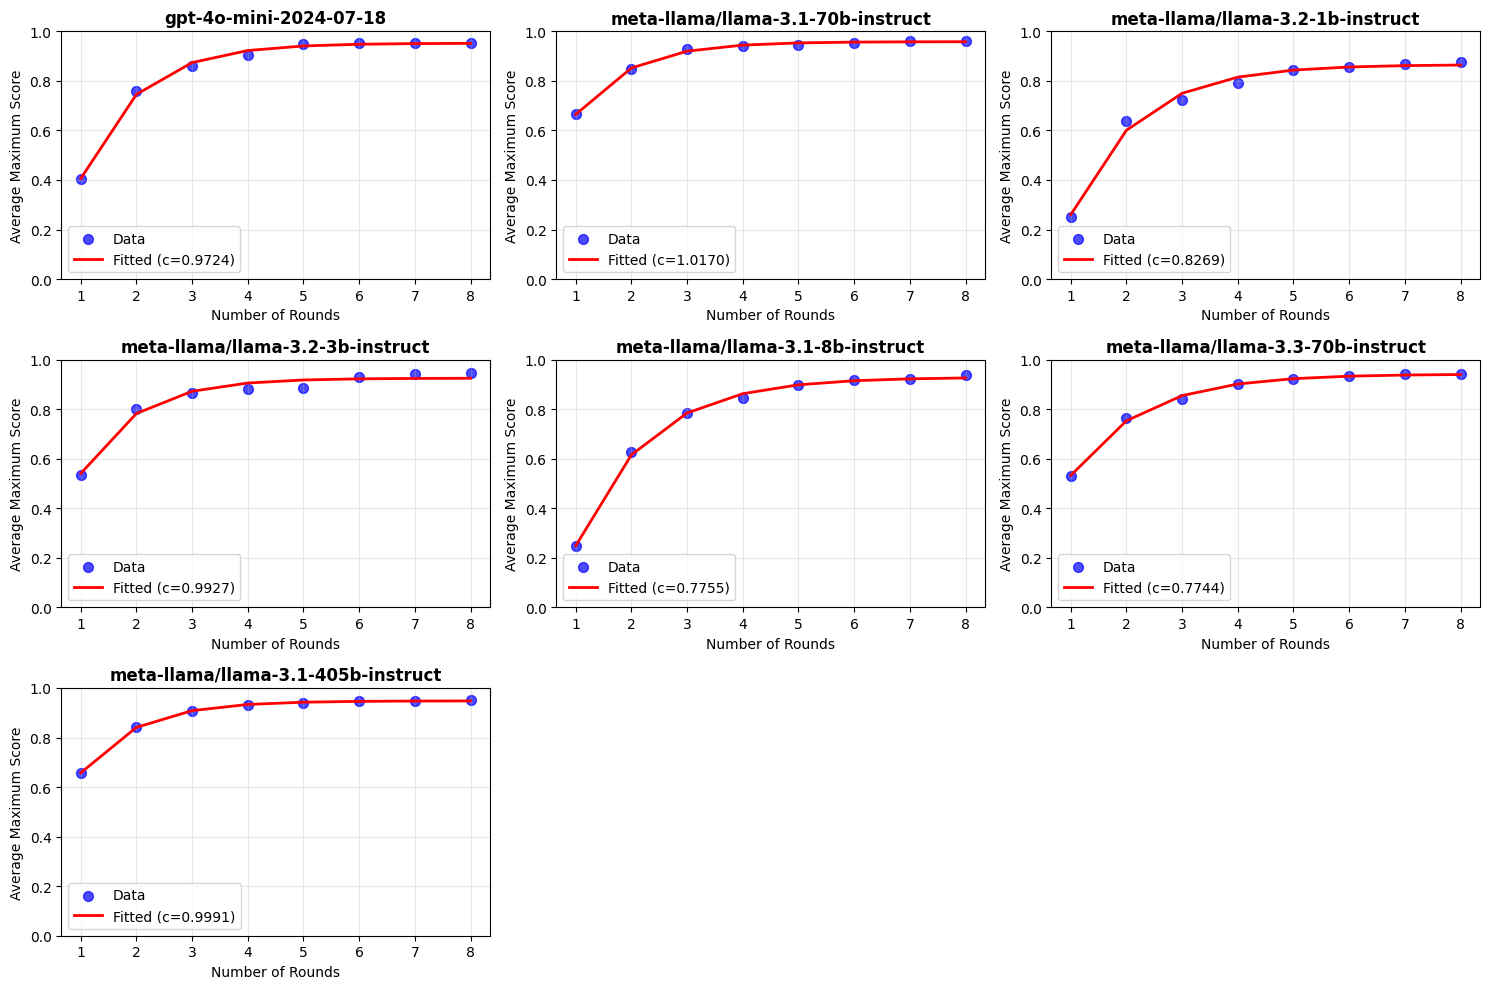

In [8]:
# Plot results
plot_max_scores_by_model(metadata)

In [9]:
# Show specific example
results = analyze_max_scores_by_model(metadata)
if results:
    # Get first model as example
    example_model = list(results.keys())[0]
    example_data = results[example_model]
    print(f"Example results for {example_model}:")
    print(example_data)

Example results for gpt-4o-mini-2024-07-18:
   rounds  avg_max_score
0       1       0.402778
1       2       0.761111
2       3       0.861111
3       4       0.902778
4       5       0.950000
5       6       0.952778
6       7       0.954167
7       8       0.954167


RMSE: 0.0108


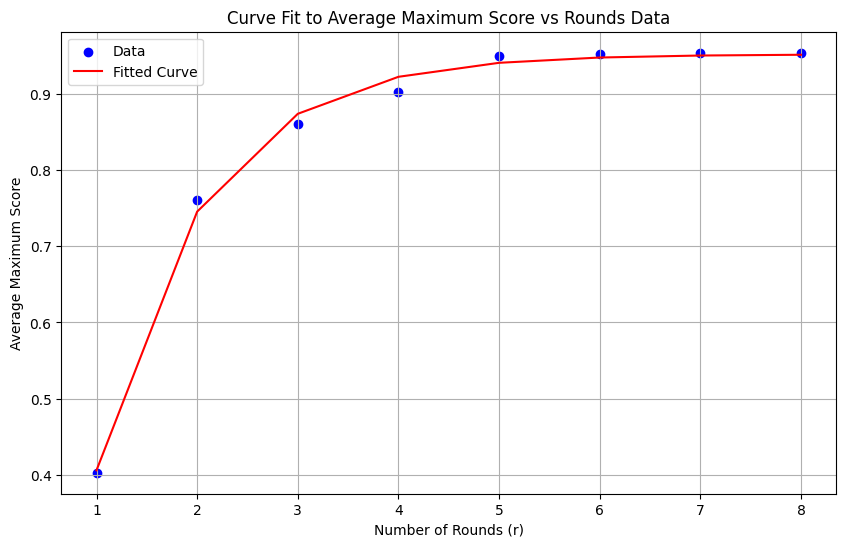

Fitted parameters:
A: 0.9521, B: 1.4441, c: 0.9724


In [10]:
# Plot curve fit for the example
if results:
    plot_curve_fit(example_data['rounds'], example_data['avg_max_score'])

In [11]:
# Load and analyze batch3A data as well
metadata3A = extract_all_metadata('clean_results/final_runs/batch3A')
print(f"Batch3A multi-turn direct_request rows: {len(metadata3A)}")
print(f"Batch3A models: {sorted(metadata3A['target_model'].unique())}")

Found 720 JSONL files to process...
Successfully processed 90 direct_request multi-turn files out of 720 total files
Batch3A multi-turn direct_request rows: 90
Batch3A models: ['anthropic/claude-3.5-sonnet', 'anthropic/claude-3.7-sonnet', 'deepseek/deepseek-chat-v3-0324', 'google/gemini-2.5-flash-preview', 'google/gemini-2.5-pro-preview-03-25', 'openai/gpt-4.1', 'openai/gpt-4.1-mini', 'openai/gpt-4.1-nano', 'openai/gpt-4o']


openai/gpt-4.1-mini - A: 0.8967, B: 1.2190, c: 0.4597, RMSE: 0.0927
openai/gpt-4.1-nano - A: 0.8023, B: 16.0502, c: 3.4643, RMSE: 0.0073
openai/gpt-4.1 - A: 0.7118, B: 0.8191, c: 0.6835, RMSE: 0.0070
deepseek/deepseek-chat-v3-0324 - A: 0.4923, B: 0.8448, c: 1.0734, RMSE: 0.0163
anthropic/claude-3.5-sonnet - A: -0.1603, B: -0.1180, c: -0.1527, RMSE: 0.0334
openai/gpt-4o - A: 1.0026, B: 0.8951, c: 0.2436, RMSE: 0.0259
anthropic/claude-3.7-sonnet - A: 0.6006, B: 0.8511, c: 0.7197, RMSE: 0.0429
google/gemini-2.5-flash-preview - A: 0.7945, B: 0.7940, c: 0.4775, RMSE: 0.0217
google/gemini-2.5-pro-preview-03-25 - A: 0.9692, B: 1.1002, c: 0.3664, RMSE: 0.0539


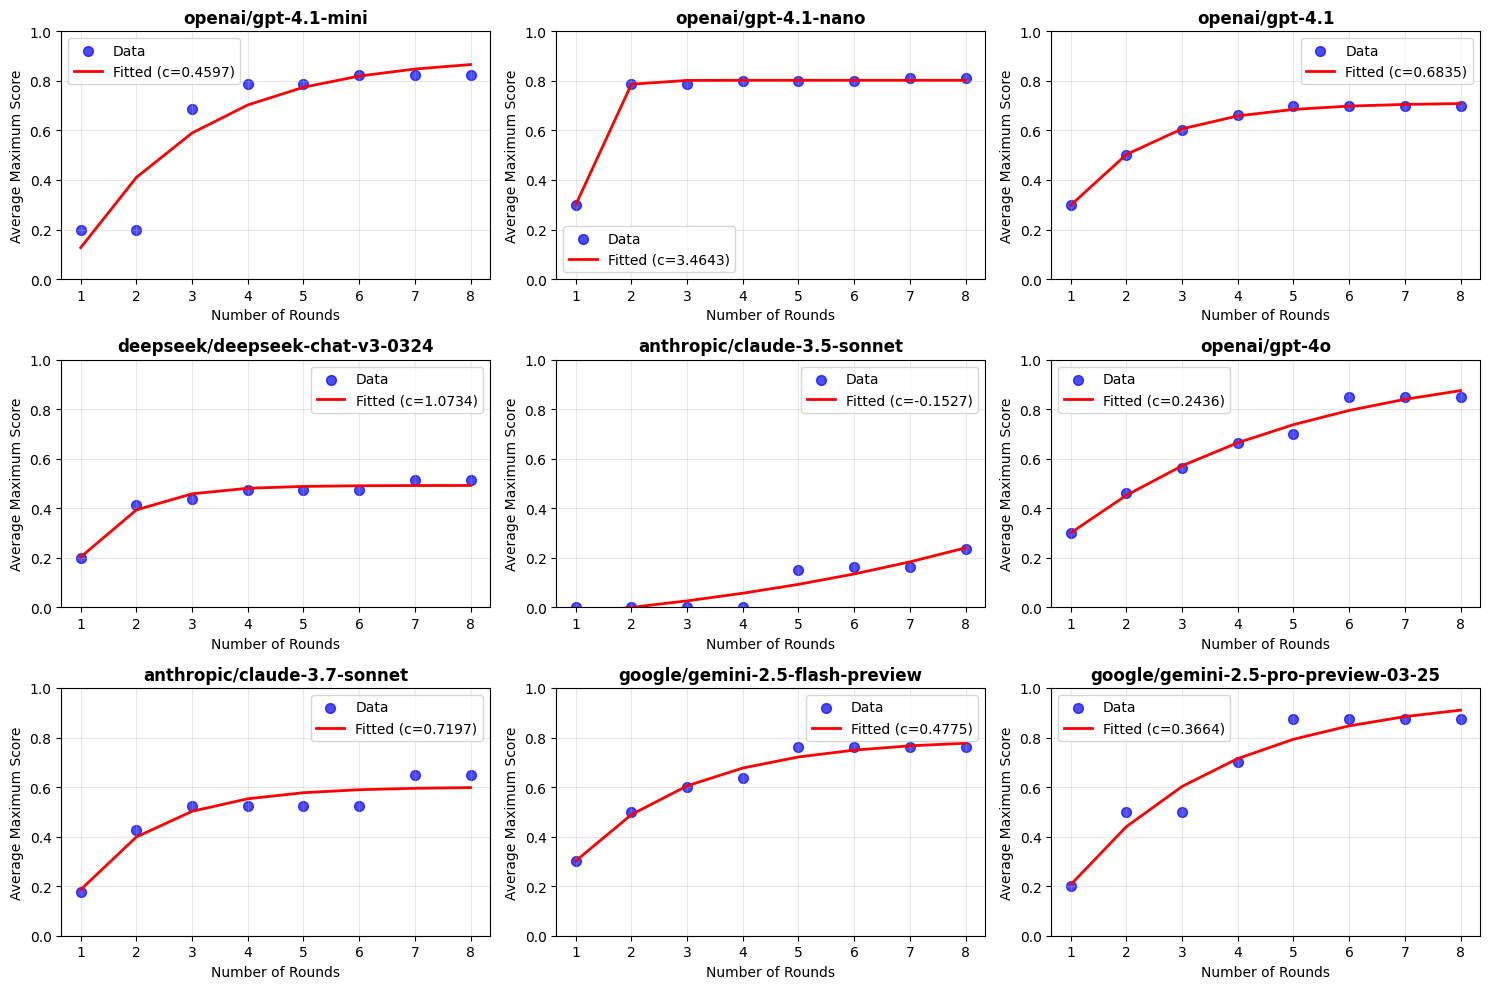

In [12]:
# Plot batch3A results
plot_max_scores_by_model(metadata3A)